In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
tickers = ['VOW3.DE', 'CON.DE', 'IFX.DE']
data = yf.download(tickers, start='2010-01-01', end='2020-12-31')['Close']
data.head()


[*********************100%***********************]  3 of 3 completed


Ticker,CON.DE,IFX.DE,VOW3.DE
Date,,,
2010-01-04,23.106653,3.388375,32.540936
2010-01-05,24.552147,3.499009,31.910301
2010-01-06,24.712759,3.451948,32.793198
2010-01-07,27.879507,3.394979,33.171577
2010-01-08,28.394667,3.451122,33.529778


In [6]:
returns = data.pct_change(periods=5)
returns.columns = ['VOW3_5d', 'CON_5d', 'IFX_5d']


In [9]:
returns['Target'] = (data['VOW3.DE'].shift(-5) > data['VOW3.DE']).astype(int)

In [8]:
returns.dropna(inplace=True)

In [10]:
train = returns.loc['2010-01-01':'2018-12-31']
test = returns.loc['2019-01-01':'2020-12-31']

X_train, y_train = train[['VOW3_5d', 'CON_5d', 'IFX_5d']], train['Target']
X_test, y_test = test[['VOW3_5d', 'CON_5d', 'IFX_5d']], test['Target']

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='linear', probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC AUC': roc_auc_score(y_test, probs)
    })

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.500990,0.528571,0.804348,0.637931,0.458199
1,KNN,0.500990,0.540816,0.576087,0.557895,0.469163
2,SVM,0.546535,0.546535,1.000000,0.706786,0.487422
3,Decision Tree,0.481188,0.526718,0.500000,0.513011,0.479258
4,Random Forest,0.481188,0.522293,0.594203,0.555932,0.463341


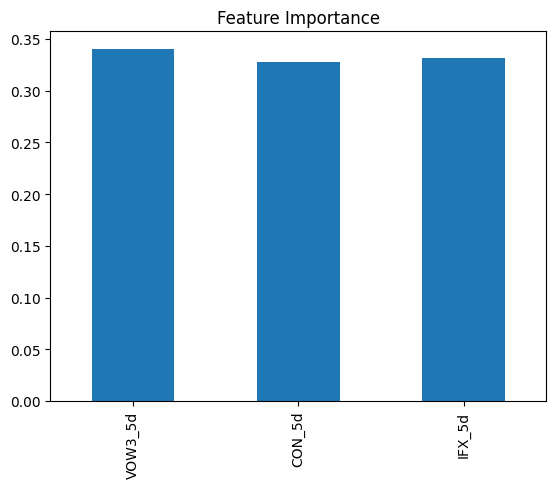

In [13]:
import matplotlib.pyplot as plt

rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=['VOW3_5d', 'CON_5d', 'IFX_5d'])
importances.plot(kind='bar', title='Feature Importance')
plt.show()